# scploid test on yanagida et al., 2022

reference: 
scploid https://github.com/MarioniLab/Aneuploidy2017/blob/master/scploid_usage.Rmd

In [40]:
library(scploid)

#here() allows us to point to files in a robust way
library(here)
fold = here()

#biomaRt allows us to get the gene locations
library(biomaRt)

#knitr tidies up some output for this document
library(knitr)

#BiocStyle is a pretty R markdown output
library(BiocStyle)

library(Seurat)

In [41]:
library(tidyverse)

In [42]:
library(Matrix)
library(dplyr)
library(stringr)

## plot parameters

In [43]:
# define const for visualization
FONT.SIZE <- 9
LABEL.FONT.SIZE <- 9
w <- 2
h <- 2.5
LINE.W <- 0.3 # equivalent to 0.75pt in Keynote

settheme <- theme_minimal() + theme(
    panel.background = element_blank(),
    panel.grid.major = element_blank(), 
    panel.grid.minor = element_blank(),
    plot.background = element_blank(),
    axis.ticks = element_line(colour = "black", linewidth = LINE.W),
    axis.line = element_line(linewidth = LINE.W, colour = "black"),
    #axis.line.y = element_blank(),
    axis.title = element_text(size = FONT.SIZE),
    axis.text = element_text(colour = "black", size = FONT.SIZE),
    axis.text.x = element_text(colour = "black", angle = 0,size = LABEL.FONT.SIZE),
    legend.position="right",
    title = element_text(size = FONT.SIZE) )


## Directory

In [44]:
figure_directory ="/nfs/team292/rs40/projects/Aneuploid_screen_v2/processed_data/4_scploid/yanagida"
dir.create(figure_directory,recursive = TRUE)
data_directory ="/nfs/team292/rs40/projects/Aneuploid_screen_v2/processed_data/4_scploid/yanagida"
dir.create(data_directory,recursive = TRUE)

Warning message in dir.create(figure_directory, recursive = TRUE):
“'/nfs/team292/rs40/projects/Aneuploid_screen_v2/processed_data/4_scploid/yanagida' already exists”
Warning message in dir.create(data_directory, recursive = TRUE):
“'/nfs/team292/rs40/projects/Aneuploid_screen_v2/processed_data/4_scploid/yanagida' already exists”


In [45]:
dataset = "yanagida"
dataset_full = "xiang_2022"

## load data

data from petripoulous et al., preprocessed with help by cellgenIT using STARsolo.

In [46]:
metadata.df = read.csv( "/nfs/team292/rs40/projects/human_embryo_analysis/processed_data/meta/integration/meta_integrated.csv")

inputdirectory =  "~/tickets/cellgen_tickets/tic-4400/results/GSE171820/GSE171820_pt1/output/GeneFull/raw/"
setwd(inputdirectory)

expression_matrix <- ReadMtx(
  mtx = "matrix.mtx.gz", features = "features.tsv.gz",
  cells = "barcodes.tsv.gz")

In [47]:
expression_matrix[1:10,1:10]

  [[ suppressing 10 column names ‘GSM5234744’, ‘GSM5234745’, ‘GSM5234746’ ... ]]



10 x 10 sparse Matrix of class "dgCMatrix"
                                   
MIR1302-2HG .  36 . . .  . .  . . .
FAM138A     .   . . . .  . .  . . .
OR4F5       .   . . . .  . .  . . .
AL627309.1  1 111 1 . .  . . 20 . .
AL627309.3  .   . . . .  . .  . . .
AL627309.2  .   . . . .  . .  . . .
AL627309.5  .  67 . . 2  . .  2 8 .
AL627309.4  .   . . . .  . .  . . .
AP006222.2  .   . . . . 30 .  . . .
AL732372.1  .  31 . . .  . .  . . .

In [48]:
#subset to remove low quality cells
metadata.df = metadata.df %>% subset(manual_celltype_annotation != "low quality")
expression_matrix = expression_matrix[, colnames(expression_matrix) %in% metadata.df[['cell.ID']]]

In [49]:
head(metadata.df )

,cell.ID,cell.name,embryo,developmental.stage,cell.state,dataset,scrublet_score,scrublet_prediction,scrublet_cluster_score,scrublet_zscore,⋯,log_prob_singleton,log_prob_doublet,cluster0,cluster1,cluster2,level_0,fastq_x,Description,fastq_y,Unnamed..0
,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>
1,ERS1079290,E3.45.3374,E3.45,3,1.Pre-morula,petropoulos_2016,0.03857567,False,0.03172414,-1.402476,⋯,NA,NA,NA,NA,NA,,,,,
2,ERS1079291,E3.45.3375,E3.45,3,1.Pre-morula,petropoulos_2016,0.02964960,False,0.03172414,-1.402476,⋯,NA,NA,NA,NA,NA,,,,,
3,ERS1079292,E3.45.3376,E3.45,3,1.Pre-morula,petropoulos_2016,0.04654896,False,0.03172414,-1.402476,⋯,NA,NA,NA,NA,NA,,,,,
4,ERS1079293,E3.45.3377,E3.45,3,1.Pre-morula,petropoulos_2016,0.03172414,False,0.03172414,-1.402476,⋯,NA,NA,NA,NA,NA,,,,,
5,ERS1079294,E3.45.3378,E3.45,3,1.Pre-morula,petropoulos_2016,0.02766798,False,0.03172414,-1.402476,⋯,NA,NA,NA,NA,NA,,,,,
6,ERS1079295,E3.45.3379,E3.45,3,1.Pre-morula,petropoulos_2016,0.03172414,False,0.03172414,-1.402476,⋯,NA,NA,NA,NA,NA,,,,,


seurat_object <- CreateSeuratObject(counts = expression_matrix)

## scploid analysis

--reference - Tells pipeline which genome to use for alignment (by default GRCh38 2020A is used). This default argument is hardcoded and needs to be changed to your local path to the reference index file.

In [50]:
#access mart and identify chromosomes that each gene lies on

#mart <- useMart("ensembl", dataset = "hsapiens_gene_ensembl")
#listFilters(mart) %>% filter(str_detect(listFilters(mart)$name,"gene_name"))

#load presaved mart object
load("~/nfs/resource/mart")

In [51]:
mart <- biomaRt::useMart(
  biomart = "ENSEMBL_MART_ENSEMBL",
  dataset = "hsapiens_gene_ensembl",
  host    = "http://www.ensembl.org"
)

gene_table <- getBM(
  attributes = c("external_gene_name", "chromosome_name"),
  mart       = mart,
  values     = as.character(rownames(expression_matrix)),
  filters    = "external_gene_name"
)

Warning message:
“Ensembl will soon enforce the use of https.
Ensure the 'host' argument includes "https://"”


In [52]:
gene_table = gene_table[gene_table$chromosome_name %in% 1:22, ]
expression_matrix = expression_matrix[gene_table$external_gene_name, ]

In [53]:
nrow(expression_matrix )

[1] 22132

In [54]:
expression_matrix[1:10,1:10]

  [[ suppressing 10 column names ‘GSM5234744’, ‘GSM5234745’, ‘GSM5234746’ ... ]]



10 x 10 sparse Matrix of class "dgCMatrix"
                                  
TRAPPC12-AS1 .   . . . . . . . . .
LINC01247    .   . . . . . . . . .
MSGN1        .   . . . . . . . . .
EIPR1-IT1    .   . . . . . . . . .
HS1BP3-IT1   .   . . . . . . . . .
LINC02850    .   . . . . . . . . .
LINC01866    . 168 . . . . . . . .
LINC01318    .   . . . . . . . . .
LINC01809    .   . . . . . . . . .
LINC01867    .   . . . . . . . . .

In [55]:
#as.matrix(expression_matrix)

In [56]:
ploidytest = makeAneu(counts = as.matrix(expression_matrix), 
                      genes = gene_table$external_gene_name, 
                      chrs = gene_table$chromosome_name, 
                      cellNames = colnames(expression_matrix), 
                      cellGroups = rep("0", ncol(expression_matrix)))

p.thresh: post FDR correction p-value for aneuploidy calling (default 0.1)

min.deviation: minimum deviation of sij
 from 1 for aneuploidy calling (default 0.2, i.e. 0.8<sij<1.2
 will never be considered as aneuploid)

center.cells: logical value to allow or prevent within-cell sij
 centering (default TRUE)

min.median: minimum CPM median value for gene retention for analysis (default 50)

extreme.gene.thresh: maximum agij
 that one gene may show before removal as outlier (default 10, to exclude no genes set to a very high value e.g. Inf)



In [57]:
ploidytest = doAneu(ploidytest)

In [58]:
metrics = getMetrics(ploidytest)

In [59]:
assessMetrics(ploidytest)

residuals             ngenes              zeros 
"Exercise Caution"     "Good quality"     "Good quality"

In [60]:
#conditions for aneuploidy
# 0.8 < S < 1.2
# P < 0.05

ploidydf <- ploidytest@scores
ploidydf$ploidy <- "normal"
for(i in 1:nrow(ploidydf)){
    if(ploidydf$monosomy[i] && ploidydf $p.adj[i]<5e-2 && ploidydf$score[i]<=0.8){
        ploidydf $ploidy[i] <- "monosomy"
    }else if(!ploidydf $monosomy[i] && ploidydf $p.adj[i]<5e-2 && ploidydf$score[i]>=1.2){
        ploidydf $ploidy[i] <- "trisomy"
    }  
}

ploidydf$chr = as.factor(ploidydf$chr)


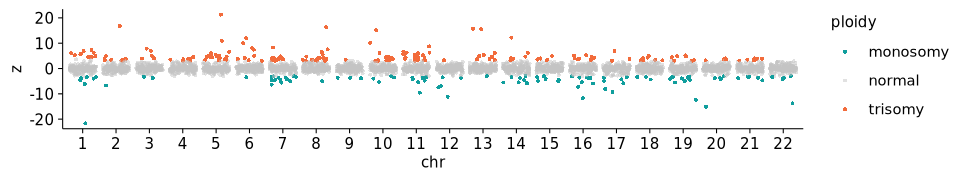

In [61]:
#plot
title = "z_score_jitter"

w <- 8
h <- 1.5

options(repr.plot.width=w, repr.plot.height=h)

z_score_jitter = ggplot(ploidydf,aes(chr,z,col=ploidy))+
                settheme+
                geom_jitter(size=0.8,shape=16)+
                scale_color_manual(values=c("normal"=adjustcolor("grey77", alpha = 0.5),"monosomy"="#109E9D","trisomy"="#F26B3B"))

ggsave(plot = z_score_jitter, filename = sprintf("%s/%s.pdf",figure_directory, title), w = w, h = h)

z_score_jitter

Warning message:
“Removed 22 rows containing missing values or values outside the scale range
(`geom_bar()`).”
Warning message:
“Removed 22 rows containing missing values or values outside the scale range
(`geom_bar()`).”


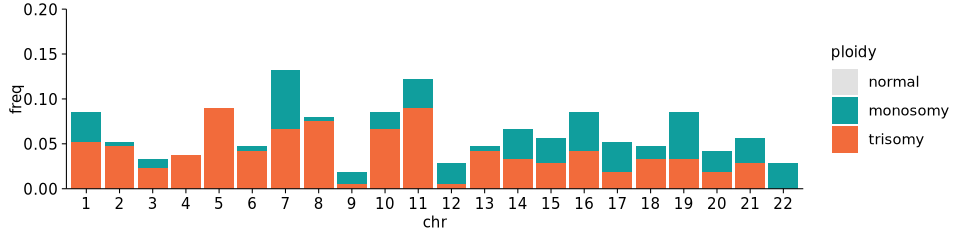

In [62]:
#plot
title = "freq_perchr_bar"

w <- 8
h <- 2

options(repr.plot.width=w, repr.plot.height=h)

order = c("normal","monosomy","trisomy")
ploidydf$ploidy <- factor(ploidydf$ploidy, levels = order)

gg_bar = ggplot(ploidydf, aes(x=chr, fill=ploidy)) +
  geom_bar(position='fill')+
  settheme+
  scale_y_continuous(expand = c(0, 0), limits = c(0, 0.2), breaks = seq(0, 0.2, by = 0.05))+
  labs(y= "freq")+
  scale_fill_manual(values=c("normal"=adjustcolor("grey77", alpha = 0.5),"monosomy"="#109E9D","trisomy"="#F26B3B"))

ggsave(plot = gg_bar, filename = sprintf("%s/%s.pdf",figure_directory, title), w = w, h = h)
gg_bar

In [63]:

write.csv(
  ploidydf,
  "/nfs/team292/rs40/projects/Aneuploid_screen_v2/processed_data/4_scploid/ploidydf_yanagida.csv",
  row.names = FALSE
)


## combine with scRNAseq analysis

aiming to try and plot against developmental time, and cell type.

In [65]:
head(ploidydf)

,chr,cell,z,score,p,p.adj,monosomy,ploidy
,<fct>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<fct>
0.1,1,GSM5234744,0.26575576,1.0009051,0.7906868,0.9999873,FALSE,normal
0.2,10,GSM5234744,0.82962673,1.0787695,0.4076875,0.9650156,FALSE,normal
0.3,11,GSM5234744,-0.09427572,0.9806102,0.9249796,0.9999873,TRUE,normal
0.4,12,GSM5234744,-0.48377994,0.9463207,0.6290437,0.9999873,TRUE,normal
0.5,13,GSM5234744,0.44158918,1.0492307,0.6592387,0.9999873,FALSE,normal
0.6,14,GSM5234744,-0.69157305,0.9498556,0.4899657,0.9969082,TRUE,normal


In [66]:
metadata.df$cell = as.factor(metadata.df$cell.ID)

In [67]:
joint_meta <- merge(metadata.df, ploidydf, by = 'cell')
head(joint_meta)
nrow(joint_meta)

,cell,cell.ID,cell.name,embryo,developmental.stage,cell.state,dataset,scrublet_score,scrublet_prediction,scrublet_cluster_score,⋯,Description,fastq_y,Unnamed..0,chr,z,score,p,p.adj,monosomy,ploidy
,<fct>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<dbl>,⋯,<chr>,<chr>,<chr>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<fct>
1,GSM5234744,GSM5234744,Day7.1.pTEICM_3,Day7.1.,7,Trophectoderm,yanagida_2021,0.05555556,False,0.06896552,⋯,,,,1,0.26575576,1.0009051,0.7906868,0.9999873,FALSE,normal
2,GSM5234744,GSM5234744,Day7.1.pTEICM_3,Day7.1.,7,Trophectoderm,yanagida_2021,0.05555556,False,0.06896552,⋯,,,,10,0.82962673,1.0787695,0.4076875,0.9650156,FALSE,normal
3,GSM5234744,GSM5234744,Day7.1.pTEICM_3,Day7.1.,7,Trophectoderm,yanagida_2021,0.05555556,False,0.06896552,⋯,,,,11,-0.09427572,0.9806102,0.9249796,0.9999873,TRUE,normal
4,GSM5234744,GSM5234744,Day7.1.pTEICM_3,Day7.1.,7,Trophectoderm,yanagida_2021,0.05555556,False,0.06896552,⋯,,,,12,-0.48377994,0.9463207,0.6290437,0.9999873,TRUE,normal
5,GSM5234744,GSM5234744,Day7.1.pTEICM_3,Day7.1.,7,Trophectoderm,yanagida_2021,0.05555556,False,0.06896552,⋯,,,,13,0.44158918,1.0492307,0.6592387,0.9999873,FALSE,normal
6,GSM5234744,GSM5234744,Day7.1.pTEICM_3,Day7.1.,7,Trophectoderm,yanagida_2021,0.05555556,False,0.06896552,⋯,,,,14,-0.69157305,0.9498556,0.4899657,0.9969082,TRUE,normal


[1] 4664

In [68]:
#subset to quanity per cell
joint_meta_sub = joint_meta %>% arrange(factor(ploidy, levels = c("trisomy","monosomy", "normal")))
joint_meta_sub = joint_meta_sub[!duplicated(joint_meta_sub[,c('cell')]),]
nrow(joint_meta_sub)
head(joint_meta_sub)

[1] 212

,cell,cell.ID,cell.name,embryo,developmental.stage,cell.state,dataset,scrublet_score,scrublet_prediction,scrublet_cluster_score,⋯,Description,fastq_y,Unnamed..0,chr,z,score,p,p.adj,monosomy,ploidy
,<fct>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<dbl>,⋯,<chr>,<chr>,<chr>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<fct>
1,GSM5234745,GSM5234745,Day7.1.pTEICM_4,Day7.1.,7,Trophectoderm,yanagida_2021,0.13829787,False,0.04985337,⋯,,,,10,10.177494,2.046197,4.757919e-20,1.386934e-17,FALSE,trisomy
9,GSM5234750,GSM5234750,Day6.3.pTEICM_5,Day6.3.,6,Trophectoderm,yanagida_2021,0.06896552,False,0.09623431,⋯,,,,14,4.736572,1.432881,3.987859e-06,1.999933e-04,FALSE,trisomy
12,GSM5234754,GSM5234754,Day7.1.pTEICM_9,Day7.1.,7,Trophectoderm,yanagida_2021,0.05555556,False,0.07294430,⋯,,,,13,3.380245,1.533391,8.627205e-04,1.741874e-02,FALSE,trisomy
13,GSM5234759,GSM5234759,Day6.4.pTEICM_3,Day6.4.,6,Epiblast,yanagida_2021,0.18181818,False,0.09108590,⋯,,,,21,3.151857,1.541494,1.858243e-03,3.246009e-02,FALSE,trisomy
14,GSM5234767,GSM5234767,Day7.2.pTEICM_23,Day7.2.,7,Trophectoderm,yanagida_2021,0.12195122,False,0.04985337,⋯,,,,6,3.240742,1.325013,1.385323e-03,2.594838e-02,FALSE,trisomy
15,GSM5234768,GSM5234768,Day6.4.pTEICM_11,Day6.4.,6,Epiblast,yanagida_2021,0.10810811,False,0.10810811,⋯,,,,14,3.857358,1.354644,1.522497e-04,4.303591e-03,FALSE,trisomy


In [69]:
#add information of summarised ploidy (euploi or aneuplploid)
joint_meta$euploid_aneuploid <- ifelse(joint_meta$ploidy == "normal", "euploid", "aneuploid")

## Analyse per cell

In [70]:
#dataframe to plot ploidy type per cell

joint_meta_sub = joint_meta %>% arrange(factor(ploidy, levels = c("trisomy","monosomy", "normal")))
joint_meta_sub = joint_meta_sub[!duplicated(joint_meta_sub[,c('cell')]),]

meta_df = joint_meta 

meta_df_ploidy = meta_df[meta_df$ploidy != "normal", ] 

#label ploidy type 
meta_df_ploidy = meta_df_ploidy %>%
    select(cell, ploidy)%>%
    group_by(cell) %>% 
    arrange(factor(ploidy, levels = c("monosomy", "trisomy","normal"))) %>% 
    mutate(ploidy = str_c(ploidy, collapse="_"))%>% 
    distinct() 

#relabel the ploidy
meta_df_ploidy = meta_df_ploidy %>%
  mutate(ploidy = case_when(ploidy == "monosomy" ~ "monosomy" , 
                            ploidy == "trisomy" ~ "trisomy" , 
                              .default = "complex")
)

#combine with the original dataframe
joint_meta_sub_ploidy = merge(joint_meta_sub, meta_df_ploidy, by = 'cell' , all.x=TRUE )

joint_meta_sub_ploidy$ploidy.y = joint_meta_sub_ploidy$ploidy.y %>% 
       replace_na('euploid')

#order for plotting 
order = c("euploid","monosomy","trisomy","complex" )
joint_meta_sub_ploidy$ploidy.y <- factor(joint_meta_sub_ploidy$ploidy.y, levels = order)

#for general ploidy rates 
joint_meta_sub_ploidy$euploid_aneuploid <- ifelse(joint_meta_sub_ploidy$euploid_aneuploid  == "euploid", "euploid", "aneuploid")

### Developmental time

In [71]:
#dataframe to obtain total number of aneupliod cells per developmental stage
ploidy_days = 
joint_meta_sub_ploidy %>%
  group_by(developmental.stage, euploid_aneuploid) %>%
  summarise(count = n()) %>%
  mutate(per = count / sum(count)) %>%
  mutate(total =sum(count)) %>% 
  subset(euploid_aneuploid == "aneuploid")%>%
  rename(ploidy.y = euploid_aneuploid)

#dataframe to obtain values per developmental stage
joint_meta_sub_ploidy_days = 
joint_meta_sub_ploidy %>%
  group_by(developmental.stage, ploidy.y) %>%
  summarise(count = n()) %>%
  mutate(per = count / sum(count)) %>%
  mutate(total =sum(count))

joint_meta_sub_ploidy_days = rbind (ploidy_days, joint_meta_sub_ploidy_days)

`summarise()` has grouped output by 'developmental.stage'. You can override
using the `.groups` argument.
`summarise()` has grouped output by 'developmental.stage'. You can override
using the `.groups` argument.


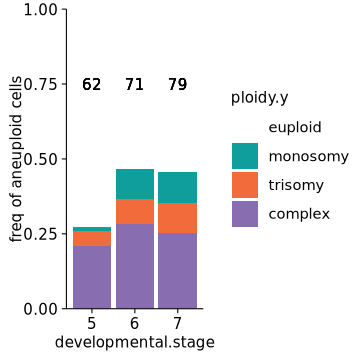

In [72]:
#plot
title = "freq_per_devstage_bar_ploidy_count"

w <- 3
h <- 3
options(repr.plot.width=w, repr.plot.height=h)

sub = joint_meta_sub_ploidy_days

joint_meta_sub_ploidy_days =
 joint_meta_sub_ploidy_days %>% 
    subset(!ploidy.y %in% c("aneuploid"))

order = c("euploid","monosomy","trisomy","complex" )
joint_meta_sub_ploidy_days$ploidy.y <- factor(joint_meta_sub_ploidy_days$ploidy.y, levels = order)

ggbar = ggplot(joint_meta_sub_ploidy_days, aes(x=developmental.stage, y=per, fill = ploidy.y)) +
          geom_bar(stat="identity")+
          settheme+
          scale_y_continuous(expand = c(0, 0), limits = c(0, 1))+
          labs(y= "freq of aneuploid cells")+
          scale_fill_manual(values=c("euploid"= "white","monosomy"="#109E9D","trisomy"="#F26B3B","complex"= "#886DB0"))+
          theme(axis.text.x = element_text(colour = "black", angle = 0))+
          geom_text(aes(x = developmental.stage,y=0.75, label = total, fill = NULL), size = 9/.pt)
  
ggsave(plot = ggbar, filename = sprintf("%s/%s.pdf",figure_directory, title), w = w, h = h)
ggbar

joint_meta_sub_ploidy_days = sub

In [73]:
head(joint_meta_sub_ploidy)

,cell,cell.ID,cell.name,embryo,developmental.stage,cell.state,dataset,scrublet_score,scrublet_prediction,scrublet_cluster_score,⋯,Unnamed..0,chr,z,score,p,p.adj,monosomy,ploidy.x,euploid_aneuploid,ploidy.y
,<fct>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<dbl>,⋯,<chr>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<fct>,<chr>,<fct>
1,GSM5234744,GSM5234744,Day7.1.pTEICM_3,Day7.1.,7,Trophectoderm,yanagida_2021,0.05555556,False,0.06896552,⋯,,1,0.26575576,1.0009051,7.906868e-01,9.999873e-01,FALSE,normal,euploid,euploid
2,GSM5234745,GSM5234745,Day7.1.pTEICM_4,Day7.1.,7,Trophectoderm,yanagida_2021,0.13829787,False,0.04985337,⋯,,10,10.17749363,2.0461966,4.757919e-20,1.386934e-17,FALSE,trisomy,aneuploid,complex
3,GSM5234746,GSM5234746,Day7.1.pTEICM_8,Day7.1.,7,Trophectoderm,yanagida_2021,0.04000000,False,0.06896552,⋯,,16,-3.55180615,0.5912980,4.718547e-04,1.068316e-02,TRUE,monosomy,aneuploid,monosomy
4,GSM5234748,GSM5234748,Day6.3.pTEICM_2,Day6.3.,6,Epiblast,yanagida_2021,0.12195122,False,0.09108590,⋯,,1,-0.76082592,0.9447969,4.476104e-01,9.876810e-01,TRUE,normal,euploid,euploid
5,GSM5234749,GSM5234749,Day6.3.pTEICM_4,Day6.3.,6,Epiblast,yanagida_2021,0.13829787,False,0.06896552,⋯,,1,-0.01383288,0.9856241,9.889764e-01,9.999873e-01,TRUE,normal,euploid,euploid
6,GSM5234750,GSM5234750,Day6.3.pTEICM_5,Day6.3.,6,Trophectoderm,yanagida_2021,0.06896552,False,0.09623431,⋯,,14,4.73657216,1.4328811,3.987859e-06,1.999933e-04,FALSE,trisomy,aneuploid,complex


## Abnormal chromosome

In [74]:
#add karyotype info
karyotype_summary <- ploidydf %>%
  # Ensure chromosomes are sorted numerically for a clean final string
  arrange(cell, as.numeric(chr)) %>% 
  
  # Create a label for each row based on ploidy
  mutate(event = case_when(
    ploidy == "trisomy" ~ paste0(chr, "+"),   # Trisomy / Gain
    ploidy == "monosomy" ~ paste0(chr, "-"),   # Monosomy / Loss
    TRUE ~ NA_character_             # Normal (ploidy 2), mark as NA to ignore later
  )) %>%
  
  # Filter out the 'normal' rows so they don't clutter the string
  filter(!is.na(event)) %>%
  
  # Group by cell and collapse the events into a single string
  group_by(cell) %>%
  summarise(karyotype = paste(event, collapse = ", ")) %>%
  
  # Join back to original list of cells to ensure 'normal' cells appear
  right_join(distinct(ploidydf, cell), by = "cell") %>%
  
  # Fill in the NAs for cells that had no events
  mutate(karyotype = ifelse(is.na(karyotype), "diploid", karyotype))

#summarise the karyotype info
final_summary <- karyotype_summary %>%
  mutate(ploidy = case_when(
    # 1. Check for Normal
    karyotype == "diploid" ~ "diploid",
    
    # 2. Check for single Trisomy: Exactly one '+' AND zero '-'
    str_count(karyotype, "\\+") == 1 & str_count(karyotype, "-") == 0 ~ "trisomy",
    
    # 3. Check for single Monosomy: Exactly one '-' AND zero '+'
    str_count(karyotype, "-") == 1 & str_count(karyotype, "\\+") == 0 ~ "monosomy",
    
    # 4. Everything else (multiple events, mixed gains/losses) -> Complex
    TRUE ~ "complex"
  ))

#add number of chromosomes
cell_karyotype <- final_summary %>%
  mutate(
    # Count occurrences of "+" (escape with \\ because + is a special regex character)
    num_gain_chr = str_count(karyotype, "\\+"),
    
    # Count occurrences of "-"
    num_loss_chr = str_count(karyotype, "-"),
    
    # Apply the math: Start at 22, add gains, subtract losses
    num_chr = 22 + num_gain_chr - num_loss_chr,
    num_abnormal_chr = num_gain_chr + num_loss_chr
  )

# View result
head(cell_karyotype, 10)

cell,karyotype,ploidy,num_gain_chr,num_loss_chr,num_chr,num_abnormal_chr
<fct>,<chr>,<chr>,<int>,<int>,<dbl>,<int>
GSM5234745,"1-, 2+, 3+, 5+, 6+, 7+, 8+, 10+, 11-, 12-, 13+, 16-, 17-, 18-, 19-, 20-, 22-",complex,8,9,21,17
GSM5234746,16-,monosomy,0,1,21,1
GSM5234750,"2+, 8+, 14+, 16-, 19-, 20-, 22-",complex,3,4,21,7
GSM5234754,13+,trisomy,1,0,23,1
GSM5234757,"1-, 18-",complex,0,2,20,2
GSM5234759,21+,trisomy,1,0,23,1
GSM5234767,6+,trisomy,1,0,23,1
GSM5234768,"2+, 8+, 14+, 16-, 20-, 22-",complex,3,3,22,6
GSM5234772,"1-, 3+, 4+, 6+, 7+, 8+, 11-, 12-, 16-, 17-, 19-, 21-",complex,5,7,20,12


In [75]:
head(metadata.df)

,cell.ID,cell.name,embryo,developmental.stage,cell.state,dataset,scrublet_score,scrublet_prediction,scrublet_cluster_score,scrublet_zscore,⋯,log_prob_doublet,cluster0,cluster1,cluster2,level_0,fastq_x,Description,fastq_y,Unnamed..0,cell
,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<fct>
1,ERS1079290,E3.45.3374,E3.45,3,1.Pre-morula,petropoulos_2016,0.03857567,False,0.03172414,-1.402476,⋯,NA,NA,NA,NA,,,,,,ERS1079290
2,ERS1079291,E3.45.3375,E3.45,3,1.Pre-morula,petropoulos_2016,0.02964960,False,0.03172414,-1.402476,⋯,NA,NA,NA,NA,,,,,,ERS1079291
3,ERS1079292,E3.45.3376,E3.45,3,1.Pre-morula,petropoulos_2016,0.04654896,False,0.03172414,-1.402476,⋯,NA,NA,NA,NA,,,,,,ERS1079292
4,ERS1079293,E3.45.3377,E3.45,3,1.Pre-morula,petropoulos_2016,0.03172414,False,0.03172414,-1.402476,⋯,NA,NA,NA,NA,,,,,,ERS1079293
5,ERS1079294,E3.45.3378,E3.45,3,1.Pre-morula,petropoulos_2016,0.02766798,False,0.03172414,-1.402476,⋯,NA,NA,NA,NA,,,,,,ERS1079294
6,ERS1079295,E3.45.3379,E3.45,3,1.Pre-morula,petropoulos_2016,0.03172414,False,0.03172414,-1.402476,⋯,NA,NA,NA,NA,,,,,,ERS1079295


In [76]:
merged_cellkaryotype <- inner_join(cell_karyotype, metadata.df , by = c("cell" ))

In [78]:

write.csv(
  merged_cellkaryotype,
  "/nfs/team292/rs40/projects/Aneuploid_screen_v2/processed_data/4_scploid/cellkaryotype_yanagida.csv",
  row.names = FALSE
)


In [79]:
ab_counts <- merged_cellkaryotype %>%
  group_by(num_abnormal_chr, developmental.stage)%>%
  summarise(count= n(), .groups = "drop")
head(ab_counts)

num_abnormal_chr,developmental.stage,count
<int>,<dbl>,<int>
0,5,45
0,6,38
0,7,43
1,5,4
1,6,13
1,7,16


Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for '≥5' in 'mbcsToSbcs': >= substituted for ≥ (U+2265)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for '≥5' in 'mbcsToSbcs': >= substituted for ≥ (U+2265)”


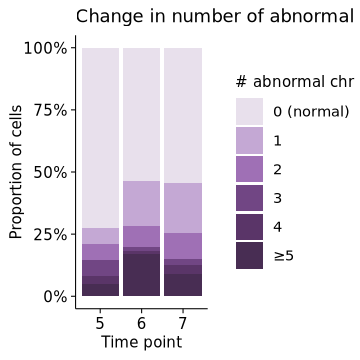

In [80]:
plot_data <- ab_counts %>%
  #filter(sample %in% rev_samples) %>%
  #mutate(time = factor(gsub("_rev", "", sample), levels = c("T1", "T2", "T3"))) %>%
  group_by(developmental.stage) %>%
  mutate(total = sum(count)) %>%
  ungroup() %>%
  mutate(prop = count / total)

title = "no_chr_affected"
bar_colours <- c(
  "0 (normal)" = "#E8E0EC",
  "1"          = "#C4A8D4",
  "2"          = "#9F70B5",
  "3"          = "#714684",
  "4"          = "#5A3568",
  "≥5"         = "#482D53"
)

bar_data <- plot_data %>%
  mutate(
    chr_group = case_when(
      num_abnormal_chr == 0 ~ "0 (normal)",
      num_abnormal_chr <= 4 ~ as.character(num_abnormal_chr),
      TRUE                  ~ "≥5"
    ),
    chr_group = factor(chr_group, levels = names(bar_colours))
  )

gg_bar <- ggplot(bar_data, aes(x = developmental.stage, y = prop, fill = chr_group)) +
  geom_bar(stat = "identity") +
  scale_y_continuous(labels = scales::percent) +
  scale_fill_manual(values = bar_colours) +
  labs(
    x    = "Time point",
    y    = "Proportion of cells",
    fill = "# abnormal chr",
    title = "Change in number of abnormal chromsomes"
  ) +
  settheme

ggsave("temporal_aneuploidy.pdf", width = 6, height = 2.5)
ggsave(plot = gg_bar, filename = sprintf("%s/M_%s.pdf",figure_directory, title), w = w, h = h)
gg_bar